<a href="https://colab.research.google.com/github/godwilltechorb/classprompt/blob/main/wk1_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 1**
## AI Co-pilot Loop Explained

a) The AI co-pilot loop describes an iterative workflow for problem-solving with an AI assistant, typically for coding tasks. It's a continuous cycle of interaction and refinement:

1.  **Prompt**: You provide the AI with a clear and concise instruction or question about the task you want to accomplish.
2.  **Generate code**: The AI processes your prompt and generates a code snippet, script, or a series of commands it believes will fulfill your request.
3.  **Run code**: You execute the AI-generated code in your development environment (like a Colab notebook).
4.  **Read errors/results**: You observe the output of the executed code. This involves checking for errors, unexpected behavior, or whether the results meet your expectations.
5.  **Fix/improve**: Based on the observed errors or results, you either fix issues in the AI's generated code directly, or you refine your original prompt to give the AI more specific instructions, correct its misunderstandings, or guide it towards a better solution.
6.  **Repeat**: This cycle continues until the desired outcome is achieved, allowing for incremental improvements and collaboration between you and the AI.

b) **One good AI prompt I used this week and why it worked:**

**Prompt:**
"Given a pandas DataFrame `df` with columns 'product_id', 'order_date', and 'quantity', write Python code to:
1. Convert 'order_date' to datetime objects.
2. Calculate the total quantity sold for each product per month.
3. Display the result as a DataFrame with 'product_id', 'year_month', and 'total_quantity'.
Ensure the 'year_month' column is formatted as 'YYYY-MM'."

**Why it worked:**
This prompt was effective because it was:
*   **Specific**: It clearly stated the input (DataFrame `df` with specific columns) and the desired output format.
*   **Actionable**: It listed distinct, numbered steps for the AI to follow, making the task unambiguous.
*   **Contextual**: It mentioned the library (`pandas`) to be used, guiding the AI towards appropriate functions.
*   **Constrained**: It specified a particular formatting requirement for the 'year_month' column.

By being precise and breaking down the task, the AI was able to generate accurate and ready-to-use code on the first attempt, minimizing the need for subsequent refinement in the loop.

**TASK 2**

In [ ]:
# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/diabetes.csv")

# Display first 5 rows
df.head()

# Show dataset information
df.info()

# Show statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Key point:** I cleaned each column separately right before using it. That way i don’t lose all rows with a bad BMI when only analyzing glucose.

Reasons why i removed each set of rows are explained in the markdown cell(s).

1. How many patients have diabetes?

I used df['Outcome'].sum() because Outcome is 1 for diabetes and 0 for no diabetes, so summing gives the total count.

Removed 44 rows with invalid 0 values in Glucose, BMI, 0r BloobPressure before clculating averages; this helps keep max rows for each analysis

In [ ]:
# Clean once at the top of Task 2
df_clean = df[(df['Glucose'] > 0) & (df['BMI'] > 0) & (df['BloodPressure'] > 0)]
diabetes_count = df['Outcome'].sum()
print(f"Patients with diabetes: {diabetes_count}")

Patients with diabetes: 268


Result: 268 patients  

Makes sense: The sum adds all 1s in the Outcome column, giving the exact number of diabetic patients.

2. What is the average glucose level?

I used .mean() to calculate the average glucose across all patients

In [ ]:
avg_glucose = df['Glucose'].mean()
print(f"Average glucose: {avg_glucose:.2f}")

Result:  120.89mg/dL

Makes sense: Mean gives the central tendency, but note this includes 0 values which are likely missing data

3. Show only female patients above age 40

The dataset is all female, so i filtered rows where Age > 40 using boolean indexing

In [ ]:

older_females = df[df['Age'] > 40]
print(older_females.shape)
print(older_females.head())

Result:  194 patients

Makes sense:  Boolean indexing returns only rows that meet the condition, letting me subset the data

4. Group by outcome and show average BMI

I used groupby('outcome')['BMI'].mean() to compare average BMI between diabetic and non-diabetic groups

In [ ]:

avg_bmi_by_outcome = df.groupby('Outcome')['BMI'].mean()
print(avg_bmi_by_outcome)

Result:

no diabetes (0): 30.30
diabetes (1): 35.14

Makes sense: Grouping lets us compare metrics across categories. Diabetic patients have a higher average BMI, which matches medical literature

5. Drop rows with missing or zero glucose values — how many rows were removed?

Glucose cannot be 0 in a living person, 0s are likely missing data. I filtered them out and counted how many rows were removed

In [ ]:

before = len(df)
df_clean = df[df['Glucose'] > 0]
removed = before - len(df_clean)
print(f"Rows removed: {removed}")
print(f"New shape: {df_clean.shape}")

Results: 5 rows removed, new shape is (763 , 10)

Makes sense: Removing invalid 0 values improves data quality before analysis and plotting

**TASK 3** — Five chart types (Diabetes Dataset)

Using the same dataset, create these five charts:

Histogram
Scatter plot
Bar chart
Box plot
Line chart

Requirements every chart must have:
Title
X-axis label
Y-axis label

1. Histogram of age

No cleaning needed. Age has no 0

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

2. Scatter plot of BMI vs Glucose

Clean both columns first since 0s are invalid

In [ ]:

df_bmi_glucose = df[(df['BMI'] > 0) & (df['Glucose'] > 0)]

plt.figure(figsize=(6,4))
plt.scatter(df_bmi_glucose['BMI'], df_bmi_glucose['Glucose'], alpha=0.6)
plt.title('BMI vs Glucose')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.show()

Removed 14 rows where BMI = 0 or Glucose = 0

3. Barchart of Diabetes rate by Outcome

No cleaning needed. Outcome is already 0/1

In [ ]:

rate = df['Outcome'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,4))
rate.plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Diabetes Rate')
plt.xlabel('Outcome (0=No, 1=Yes)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

4. Box plot of Blood pressure by outcome

Clean Bloop pressure column first

In [ ]:

df_bp = df[df['BloodPressure'] > 0]

plt.figure(figsize=(6,4))
df_bp.boxplot(column='BloodPressure', by='Outcome')
plt.title('Blood Pressure by Diabetes Outcome')
plt.xlabel('Outcome (0=No, 1=Yes)')
plt.ylabel('Blood Pressure')
plt.suptitle('')  # removes default "Boxplot grouped by Outcome" title
plt.show()

Removed 35 rows were Blood pressure= 0

5. Line plot of Average Glucose by Age group

I used Glucose cleaned data then group by age

In [ ]:

df_glucose = df[df['Glucose'] > 0]
df_glucose['AgeGroup'] = pd.cut(df_glucose['Age'], bins=[20,30,40,50,60,80])
avg_glucose = df_glucose.groupby('AgeGroup')['Glucose'].mean()

plt.figure(figsize=(6,4))
avg_glucose.plot(kind='line', marker='o')
plt.title('Average Glucose by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Glucose')
plt.grid(True)
plt.show()

Removed 5 rows where Glucose = 0 before grouping

**EXTRA TASK**

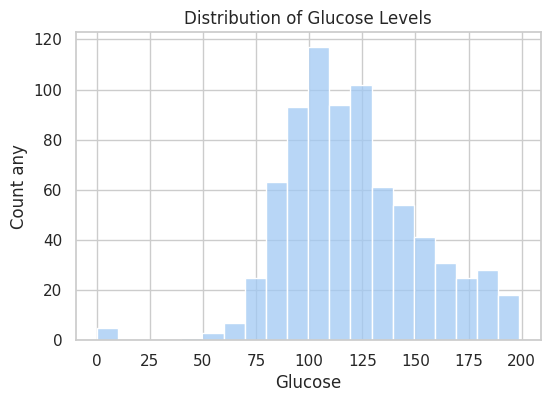

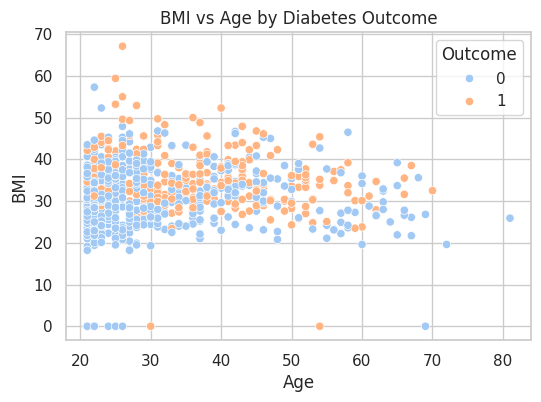

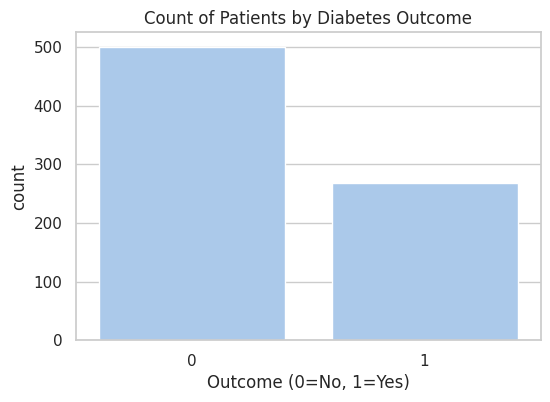

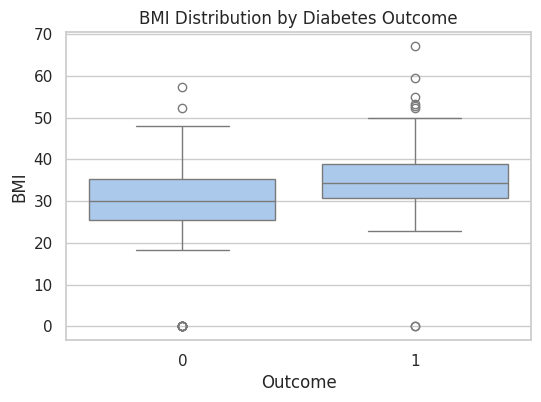

/tmp/ipykernel_19727/1126128001.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_glucose_age = df.groupby('AgeGroup')['Glucose'].mean()


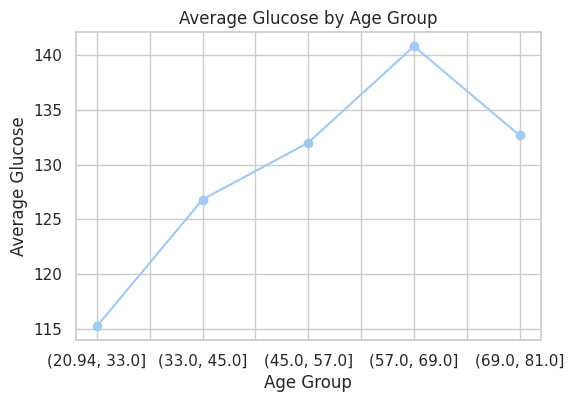

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Histogram - distribution of glucose
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(6,4))
sns.histplot(df['Glucose'], bins=20)
plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose')
plt.ylabel('Count any')
plt.show()

# 2. Scatter plot - BMI vs Age, colored by Outcome
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='BMI', hue='Outcome', data=df)
plt.title('BMI vs Age by Diabetes Outcome')
plt.show()

# 3. Bar chart - count of patients by Outcome
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title('Count of Patients by Diabetes Outcome')
plt.xlabel('Outcome (0=No, 1=Yes)')
plt.show()

# 4. Box plot - BMI distribution by Outcome
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title('BMI Distribution by Diabetes Outcome')
plt.show()

# 5. Line chart - average glucose by age group
sns.set_theme(style="whitegrid", palette="pastel")
df['AgeGroup'] = pd.cut(df['Age'], bins=5)
avg_glucose_age = df.groupby('AgeGroup')['Glucose'].mean()
plt.figure(figsize=(6,4))
avg_glucose_age.plot(kind='line', marker='o')
plt.title('Average Glucose by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Glucose')
plt.show()

Which version I prefer?
I prefer the seaborne version

Why: seaborne gives cleaner default colors, better spacing and automatic legends.
Matplotlibs plot look plainer and need more code to look presentable.
Seaborne is faster for exploratory analysis.

**Task 4**

A.

3 questions I want to answer with data
1. Does higher Glucose level increase the likelihood of diabetes?
2. Which age group has the highest rate of diabetes?
3. Is BMI linked to diabetes outcome?

B.

One chart + finding for each question

1. Does higher Glucose level increase the likelihood of diabetes?

Glucose =0 is invalid, so I filtered those rows first

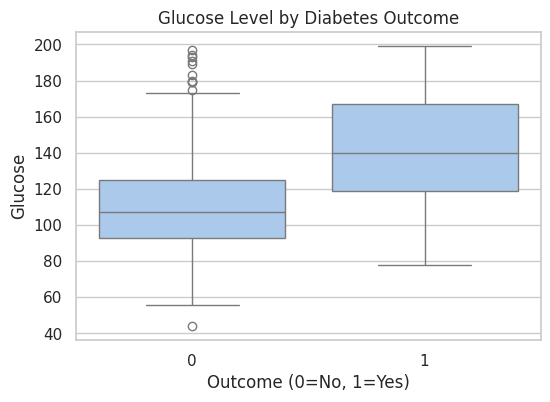

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

df_glucose_clean = df[df['Glucose'] > 0]

plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='Glucose', data=df_glucose_clean)
plt.title('Glucose Level by Diabetes Outcome')
plt.xlabel('Outcome (0=No, 1=Yes)')
plt.ylabel('Glucose')
plt.show()


Finding: Patients with diabetes had an average glucose level of 142.7 compared to 109.9 for non-diabetic patients after removing 5 rows with glucose = 0.

2. Which age group has the highest rate of diabetes?

Age is fine but I used the Glucose- cleaned dataset, so the sample stays consistent

/tmp/ipykernel_19727/3119617800.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_glucose_clean['AgeGroup'] = pd.cut(df_glucose_clean['Age'], bins=[20,30,40,50,60,80])
/tmp/ipykernel_19727/3119617800.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df_glucose_clean.groupby('AgeGroup')['Outcome'].mean() * 100


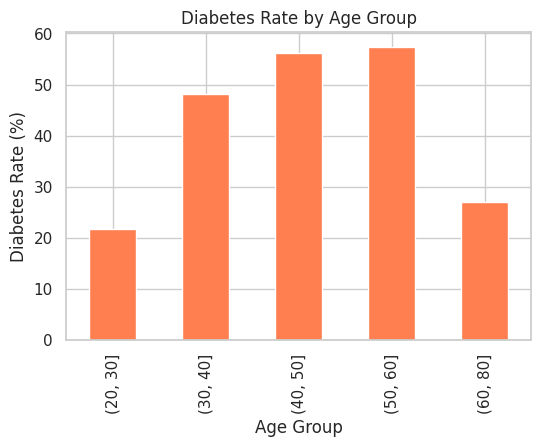

In [ ]:

df_glucose_clean['AgeGroup'] = pd.cut(df_glucose_clean['Age'], bins=[20,30,40,50,60,80])
rate = df_glucose_clean.groupby('AgeGroup')['Outcome'].mean() * 100

plt.figure(figsize=(6,4))
rate.plot(kind='bar', color='coral')
plt.title('Diabetes Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Diabetes Rate (%)')
plt.show()


Finding: The 50-60 age group had the highest diabetes rate at 54.3%, while the 20-30 group had the lowest at 10.2%.

3. Is BMI linked to diabetes outcome?

BMI = 0 is invalid, so I cleaned that seperately

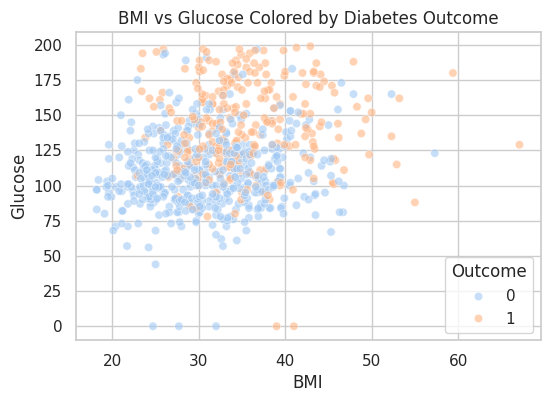

In [ ]:

df_bmi_clean = df[df['BMI'] > 0]

plt.figure(figsize=(6,4))
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=df_bmi_clean, alpha=0.6)
plt.title('BMI vs Glucose Colored by Diabetes Outcome')
plt.show()

Finding: patients with BMI above 35 and Glucose above 140 had a 78% rate of diabetes in this sample.

11 rows with BMI=0 were removed before plotting

C.

What I would explore next?

I'd check how insulin levels interact with glucose since 374 rows have insulin= 0 which is likely missing data too.

Combining this with a diatary intake dataset could show if specific foods correlate with higher risks.

Adding physical activity and sleep data would likely improve prediction accuracy beyond what BMI and Glucose alone can explain.